In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.cluster import FeatureAgglomeration
from imblearn.over_sampling import RandomOverSampler
from scipy.cluster.hierarchy import linkage, dendrogram
from collections import Counter
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter
import time
import warnings

## Loading The Data
We start by loading the 20 newsgroups dataset's raw text data and insepct it to see what are we going to work with.

In [92]:
# Lets see an example of how documents from the data looks like
categories = ['talk.politics.mideast', 'sci.med']
train_data_raw = fetch_20newsgroups(subset='train', shuffle=True, random_state=42, categories=categories)
test_data_raw = fetch_20newsgroups(subset='test', shuffle=True, random_state=42, categories=categories)
print("-----The following document is labeled as:",train_data_raw.target_names[train_data_raw.target[100]],"-----\n") 
print(train_data_raw.data[100],"\n") # talk.politics.mideast document
print("-----The following document is labeled as:",train_data_raw.target_names[train_data_raw.target[900]],"-----\n")
print(train_data_raw.data[900],"\n") # sci.med document


-----The following document is labeled as: talk.politics.mideast -----

From: tclock@orion.oac.uci.edu (Tim Clock)
Subject: Re: was:Go Hezbollah!
Nntp-Posting-Host: orion.oac.uci.edu
Organization: University of California, Irvine
Lines: 92

In article <1993Apr17.153728.12152@ncsu.edu> hernlem@chess.ncsu.edu 
(Brad Hernlem) writes:
>
>In article <2BCF287A.25524@news.service.uci.edu>, tclock@orion.oac.uci.edu 
(Tim Clock) writes:
>|
>|> "Assuming"? Also: come on, Brad. If we are going to get anywhere in 
>|> this (or any) discussion, it doesn't help to bring up elements I never 
>|> addressed, *nor commented on in any way*. I made no comment on who is 
>|> "right" or who is "wrong", only that civilians ARE being used as cover 
>|> and that, having been placed "in between" the Israelis and the guerillas,
>|> they *will* be injured as both parties continue their fight.
>
>Pardon me Tim, but I do not see how it can be possible for the IDF to fail
>to detect the presence of those responsible

By examining the examples of the original raw data, We noticed that `headers`, `footers`, and `quoted` text contain a lot of irrelevant information that could mislead the classifier or information. Headers often include metadata such as sender names, email addresses, and server details, which do not contribute to the actual topic of discussion. Footers usually contain signatures, which may introduce bias, and quoted text repeats parts of previous messages, creating redundancy. Keeping these elements could cause the model to overfit to superficial patterns rather than meaningful content. 
Also that additional information might help the classifier and will make the job too easy because the header sometimes might state the `actual topic` of conversation.
To ensure the classifier learns from the content of the document itself, we will use the remove parameter to exclude these elements when loading the training and test data.

In [93]:
# Load the 20 Newsgroups dataset's training set with headers, footers, and quotes removed.
train_data = fetch_20newsgroups(subset='train', 
                                shuffle=True, 
                                random_state=42,
                                remove =("headers","footers","quotes"),
                               )

# Load the 20 Newsgroups dataset's testing set with headers, footers, and quotes removed.
test_data = fetch_20newsgroups(subset='test',
                               shuffle=True,
                               random_state=42,
                               remove=("headers","footers","quotes"),
                              )

# Get the raw documents and labels.
X_train, y_train = train_data.data, train_data.target
X_test, y_test = test_data.data, test_data.target

# Target names (class labels):
target_names = train_data.target_names
print('We can see that our 18,846 samples are divided as follows:')
print('Training data samples -',len(X_train))
print('Testing data samples -',len(X_test))
print('Number of classes -',len(target_names))


We can see that our 18,846 samples are divided as follows:
Training data samples - 11314
Testing data samples - 7532
Number of classes - 20


## Distribution of the data
It's interesting and important to see how does the data is distributed across different classes, in case of imbalanced data we might need to take some actions to overcome that.

Average number of files per class in training data: 565.70


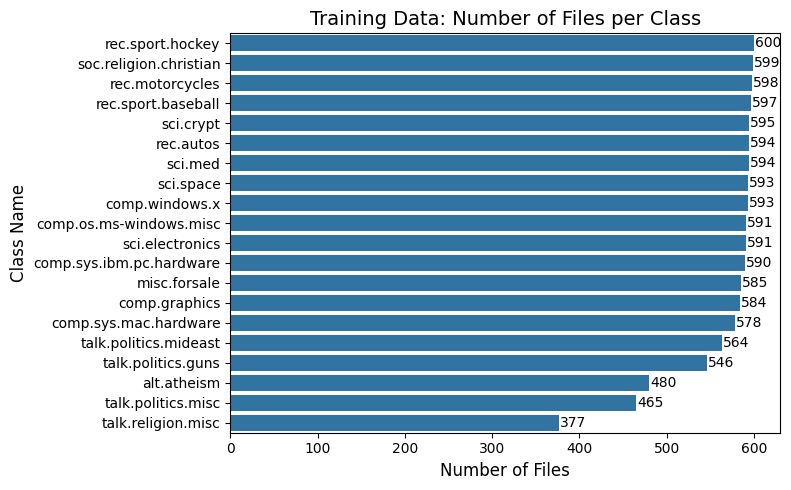

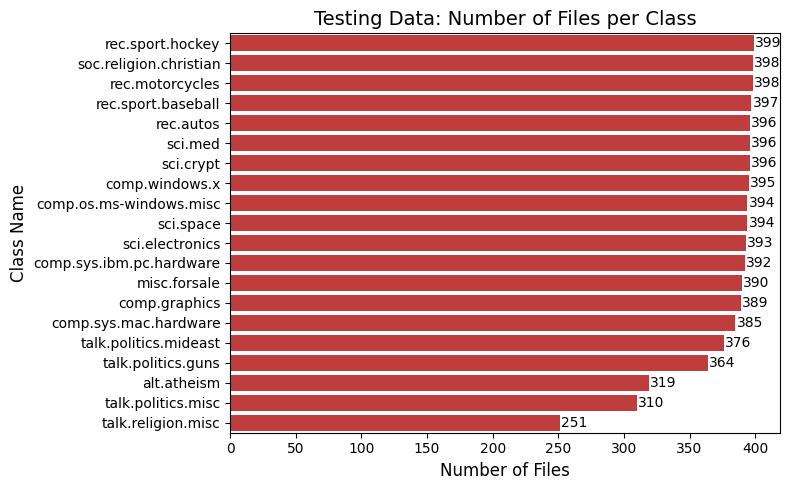

In [94]:
# Count the number of files in each class for the training and test data
train_class_counts = Counter(y_train)
test_class_counts = Counter(y_test)

# Sort by descending count
sorted_counts = sorted(train_class_counts.items(), key=lambda x: x[1], reverse=True)
classes = [target_names[idx] for idx, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

# Average files per class in train data
avg_files_per_class_train = np.mean(list(train_class_counts.values()))
print(f"Average number of files per class in training data: {avg_files_per_class_train:.2f}")

# Do the same for test data
sorted_counts_test = sorted(test_class_counts.items(), key=lambda x: x[1], reverse=True)
classes_test = [target_names[idx] for idx, _ in sorted_counts_test]
counts_test = [count for _, count in sorted_counts_test]

# Convert to DataFrames for easy plotting in Seaborn
df_train = pd.DataFrame({"Class": classes, "Count": counts})
df_test = pd.DataFrame({"Class": classes_test, "Count": counts_test})

# Plot training data with annotations
plt.figure(figsize=(8, 5))
ax_train = sns.barplot(data=df_train, x="Count", y="Class", color="C0", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Training Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Annotate each bar with its count value
for p in ax_train.patches:
    width = p.get_width()
    # p.get_y() returns the lower y coordinate of the bar, and p.get_height() gives the bar's height
    ax_train.text(width + 1, p.get_y() + p.get_height()/2, f'{int(width)}',
                  va='center', fontsize=10)

plt.tight_layout()
plt.show()


# Plot testing data with annotations
plt.figure(figsize=(8, 5))
ax_test = sns.barplot(data=df_test, x="Count", y="Class", color="C3", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Testing Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Annotate each bar with its count value
for p in ax_test.patches:
    width = p.get_width()
    ax_test.text(width + 1, p.get_y() + p.get_height()/2, f'{int(width)}',
                 va='center', fontsize=10)

plt.tight_layout()
plt.show()


The data is quite balanced in the most part, However there are some classes("talk.religion.misc" (377 files), "talk.politics.misc" (465 files) and "alt.etheism" (480 files)) that have fewer files compared to the other classes which are around 600 files each. This might lead to higher accuracy on majority classes while underpreforming on minority classes, and we might need to oversample those minority classes to overcome that difference. We will check later if oversample will help the classifiers to perform better.

## Preprocessing
We can see that our original raw data contains a lot of noise such as punctuation, numbers and special characters. 
As Tf-idf vectorizer will represent the data as a sparse matrix, if we wont remove the noise factors, they will add unnecessary dimensions that do not contribute to meaning and will increase computational cost without meaningful gains.
Also, extra noise can cause models to learn irrelevant patterns, making them less effective.
Another thing is that the data contains stop words(e.g., "the", "is", "and") which are common across all the data, meaning they do not help in distinguishing between categories so keeping them increase noise and will overshadow more meaningful words.

Concluding our wanted Preprocessing steps to execute:
1. Cleaning - Convert text to lowercase (treat "Apple" and "apple" as the same word) and remove punctuation, numbers and special characters.
2. Tokenization - Using tf-idf vectorized we will convert the raw data into vectors.
3. Stopwords Removal - Filter out common stopwords.
4. Stemming - converting words to their base form, Changing Changed Change will turn into Chang.

In [95]:
# Define a custom analyzer function that will be used to preprocess the text data.
def custom_analyzer(text):
    # 1. Cleaning & Lowercasing: Convert text to lowercase and remove non-word characters.
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    
    # 2. Tokenization: Tokenize the cleaned text.
    tokens = word_tokenize(text)
    
    # 3. Stopwords Removal: Filter out common English stopwords.
    tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS]
    
    # 4. Stemming: Convert tokens to their base form using PorterStemmer.
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    return stemmed_tokens

## Vectorization
In order to work on text data, we need to convert the data to vectorized representation.
To do so, we will use `TfidfVectorizer` and `CountVectorizer`.
We want to test and compare our classifiers performance on the output of each vectorizer and see what's best to work with.

In [96]:
# Create a TF-IDF Vectorizer with the custom analyzer.
tfidf_vect = TfidfVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_tfidf = tfidf_vect.fit_transform(X_train) # fit - learn the vocabulary and idf, transform - converting documents into document-term matrix
X_test_tfidf = tfidf_vect.transform(X_test) # transform - converting documents into document-term matrix based on the vocabulary and idf learned from the training data

print("TF-IDF train data shape:", X_train_tfidf.shape)
print("TF-IDF test data shape:", X_test_tfidf.shape)


TF-IDF train data shape: (11314, 13171)
TF-IDF test data shape: (7532, 13171)


In [97]:
count_vect = CountVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

print("CountVectorizer train data shape:", X_train_counts.shape)
print("CountVectorizer test data shape:", X_test_counts.shape)

CountVectorizer train data shape: (11314, 13171)
CountVectorizer test data shape: (7532, 13171)


## Evaluation - defining functions.
In our project we will test the following classifiers:
`Logistic regression`, `Ridge Classifier`, `Decision Tree`, `Random forest`, `LinearSVC`, `kNN` and `Complement Naive Bayes`.
we will test them each time after we will make some manipulations on the data to see what will help us get better classification results on the test data.
In order to do so we will wrap them all in a pipeline to run one by one in an organized way.

In [98]:
# Define the classifiers to test, the parameters each classifier gets are generic and not optimized.
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=10000)),
    ('Ridge Classifier', RidgeClassifier()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('LinearSVC', LinearSVC(max_iter=20000)), 
    ('KNN', KNeighborsClassifier(metric="cosine")), # by default the metric is minkowski
    ('Complement Naive Bayes', ComplementNB())
]

classifiers_predictions = {}

# Function to evaluate a classifier and return metrics
def get_classifier_metrics(clf, X_train, X_test, y_train, y_test, clf_name, to_fit=True):
    start_time = time.time()
    
    # Train the classifier if asked to.
    if to_fit == True:
        clf.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    # Make predictions.
    y_pred = clf.predict(X_test)
    classifiers_predictions[clf_name] = y_pred
    accuracy = accuracy_score(y_test, y_pred)*100
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)*100
    recall = recall_score(y_test, y_pred, average='weighted')*100
    f1 = f1_score(y_test, y_pred, average='weighted')*100
    
    return {
        'Classifier': clf_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'y_pred': y_pred
    }

def evaluate_classifiers(classifiers, X_train, X_test, y_train, y_test, dataset_label):
    """
    Evaluates each classifier on the given dataset, records the results,
    Returns the results.
    """
    results = []

    print(f"\n=== Running classifiers on {dataset_label} data ({X_train.shape[1]} features) ===\n")
    for clf_name, clf in classifiers:
        try:
            result = get_classifier_metrics(clf, X_train, X_test, y_train, y_test, clf_name)
            result['n_components'] = X_train.shape[1]
            results.append(result)
            print(f"Completed: {clf_name} on {dataset_label} data")
        except Exception as e:
            print(f"Error with {clf_name} on {dataset_label} data: {e}")
    return results

def format_results_table(df, groupby='n_components'):
    # Sort the results
    result_df = df.sort_values(by=[groupby, 'Accuracy'], ascending=[True, False]).copy()
    if 'y_pred' in result_df.columns:
        result_df.drop(columns=['y_pred'],inplace=True)
    return result_df


now let's evaluate the classifiers with tf-idf and countVectorizer, to see which one gives the better results.

In [99]:
# Evaluate classifiers on both TF-IDF and Count datasets
results_tfidf = evaluate_classifiers(classifiers, X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")
results_count = evaluate_classifiers(classifiers, X_train_counts, X_test_counts, y_train, y_test, "Count")

# Convert the results list to DataFrames
results_df_tfidf = pd.DataFrame(results_tfidf)
results_df_count = pd.DataFrame(results_count)

# Format and display the TF-IDF results table
styled_df_tfidf = (
    format_results_table(results_df_tfidf, groupby='n_components').style \
    .set_caption("Results for TF-IDF Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    }))
display(styled_df_tfidf.hide())

# Format and display the Count Vectorizer results table
styled_df_count = format_results_table(results_df_count, groupby='n_components').style \
    .set_caption("Results for Count Vectorizer Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df_count.hide())



=== Running classifiers on TF-IDF data (13171 features) ===

Completed: Logistic Regression on TF-IDF data
Completed: Ridge Classifier on TF-IDF data
Completed: Decision Tree on TF-IDF data
Completed: Random Forest on TF-IDF data
Completed: LinearSVC on TF-IDF data
Completed: KNN on TF-IDF data
Completed: Complement Naive Bayes on TF-IDF data

=== Running classifiers on Count data (13171 features) ===

Completed: Logistic Regression on Count data
Completed: Ridge Classifier on Count data
Completed: Decision Tree on Count data
Completed: Random Forest on Count data
Completed: LinearSVC on Count data
Completed: KNN on Count data
Completed: Complement Naive Bayes on Count data


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),n_components
Complement Naive Bayes,69.90%,70.72%,69.90%,69.48%,0.036997,13171
Ridge Classifier,69.07%,69.39%,69.07%,68.90%,1.407872,13171
Logistic Regression,68.37%,69.18%,68.37%,68.28%,4.027989,13171
LinearSVC,67.83%,68.26%,67.83%,67.77%,1.107152,13171
Random Forest,61.52%,61.46%,61.52%,60.83%,44.197484,13171
KNN,55.84%,58.67%,55.84%,56.28%,0.004838,13171
Decision Tree,44.33%,45.28%,44.33%,44.45%,14.139513,13171


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),n_components
Complement Naive Bayes,65.07%,65.01%,65.07%,63.34%,0.059109,13171
Logistic Regression,62.06%,62.83%,62.06%,62.12%,25.658185,13171
Random Forest,60.73%,60.66%,60.73%,59.99%,44.046417,13171
LinearSVC,57.65%,58.47%,57.65%,57.81%,13.453785,13171
Ridge Classifier,45.70%,46.85%,45.70%,45.66%,199.788899,13171
KNN,44.56%,49.04%,44.56%,44.91%,0.003549,13171
Decision Tree,44.34%,44.98%,44.34%,44.32%,9.891571,13171


We can see that working on the dense `CountVectorizer` data was pretty time consuming compared to the `TfIdfVectorizer` data.
Also the overall performance was better using tf-idf.
Before moving forward with the tf-idf data, let's see how the classifiers will do on tf-idf data WITHOUT preprocessing.

In [100]:
# Create a TF-IDF Vectorizer with the custom analyzer.
tfidf_vect_woPreproc = TfidfVectorizer(
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

X_train_tfidf_woPreproc = tfidf_vect_woPreproc.fit_transform(X_train) # fit - learn the vocabulary and idf, transform - converting documents into document-term matrix
X_test_tfidf_woPreproc = tfidf_vect_woPreproc.transform(X_test) # transform - converting documents into document-term matrix based on the vocabulary and idf learned from the training data

print("TF-IDF train data shape without preprocessing:", X_train_tfidf_woPreproc.shape)
print("TF-IDF test data shape without preprocessing:", X_test_tfidf_woPreproc.shape)

results_tfidf_woPreproc = evaluate_classifiers(classifiers, X_train_tfidf_woPreproc, X_test_tfidf_woPreproc, y_train, y_test, "TF-IDF")
results_df_tfidf_woPreproc = pd.DataFrame(results_tfidf_woPreproc)

styled_df_tfidf_woPreproc = (
    format_results_table(results_df_tfidf_woPreproc, groupby='n_components').style \
    .set_caption("Results for TF-IDF Data Without Preprocessing") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    }))
display(styled_df_tfidf_woPreproc.hide())


TF-IDF train data shape without preprocessing: (11314, 18092)
TF-IDF test data shape without preprocessing: (7532, 18092)

=== Running classifiers on TF-IDF data (18092 features) ===

Completed: Logistic Regression on TF-IDF data
Completed: Ridge Classifier on TF-IDF data
Completed: Decision Tree on TF-IDF data
Completed: Random Forest on TF-IDF data
Completed: LinearSVC on TF-IDF data
Completed: KNN on TF-IDF data
Completed: Complement Naive Bayes on TF-IDF data


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),n_components
Complement Naive Bayes,70.30%,71.17%,70.30%,69.86%,0.029994,18092
Ridge Classifier,68.44%,68.89%,68.44%,68.27%,2.469404,18092
LinearSVC,67.64%,68.08%,67.64%,67.56%,1.233990,18092
Logistic Regression,67.27%,68.22%,67.27%,67.03%,4.623903,18092
Random Forest,59.45%,59.50%,59.45%,58.65%,55.208181,18092
KNN,54.28%,57.18%,54.28%,54.58%,0.007065,18092
Decision Tree,40.93%,41.66%,40.93%,41.02%,20.591051,18092


While Complement Naive Bayes showed a minor edge with the raw text, for every other model, preprocessing produced the stronger results. From this point on, we will work on the preprocessed tf-idf data.

## Hierarchical Structure
One of the questions we want to answer is: "Does the dataset have a hierarchical structure?

In order to do so, we will first represent each class by its centroid, calculated as the average TF‑IDF vector of all documents belonging to that class. This reduces the high-dimensional document-term space to a single representative point per class. 

Then, we perform hierarchical clustering on these centroids using the Ward method, which minimizes the variance within each cluster. 

In [101]:
n_classes = len(train_data.target_names)
n_features = X_train_tfidf.shape[1]

# Initialize a matrix to hold the centroid of each class
class_centroids = np.zeros((n_classes, n_features), dtype=np.float64)
class_counts = np.zeros(n_classes, dtype=int)

for i, label in enumerate(y_train):
    # Convert the sparse row to a dense 1D array of shape (n_features,)
    row_dense = X_train_tfidf[i].toarray().ravel()
    
    class_centroids[label] += row_dense
    class_counts[label] += 1

# Divide by the number of samples in each class to get the centroid
for label in range(n_classes):
    class_centroids[label] /= class_counts[label]

print("Computed centroids for each of the 20 classes.")


Computed centroids for each of the 20 classes.


Finally, we visualize the clustering as a dendrogram to examine the relationships between classes and identify groups that may be naturally similar or prone to confusion.

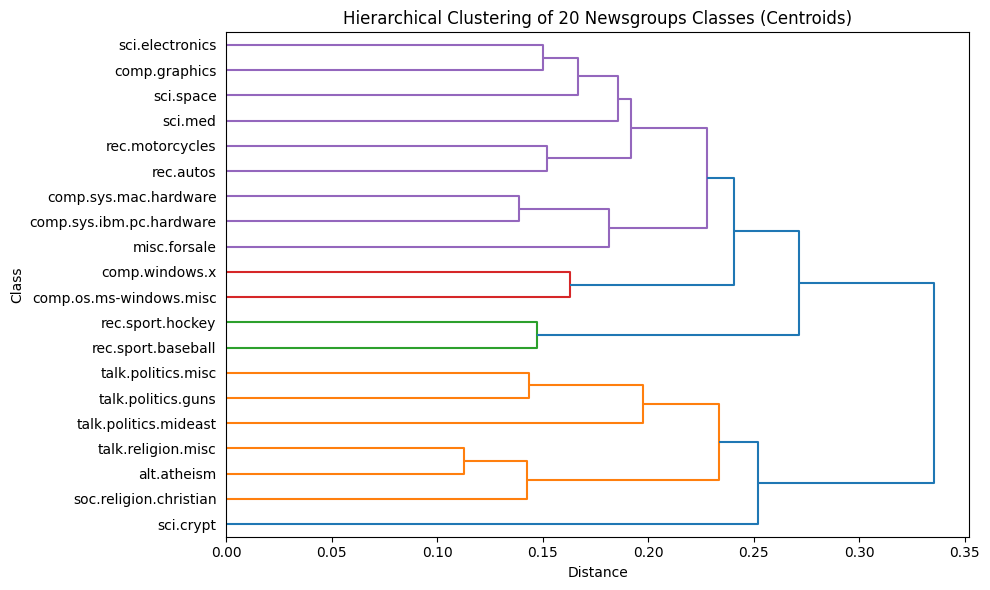

In [102]:
# Perform hierarchical clustering on the 20 class centroids
Z = linkage(class_centroids, method='ward')  

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    labels=train_data.target_names,  
    orientation='right',            
    leaf_font_size=10
)
plt.title("Hierarchical Clustering of 20 Newsgroups Classes (Centroids)")
plt.xlabel("Distance")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


The classes that merge on smaller distances are more similar to each other in terms of their average TF‑IDF vectors. This indicates they tend to share more vocabulary or have overlapping topics, so a classifier might be more likely to confuse them. 
For example, we can see that `alt.atheism` and `talk.religion.misc` are the classes the merge on the smallest distance and we can expact our classifiers to confuse them alot more than the others.
We will see if that will happen at the end in our confusion matrices.

Another thing we can get from that is to actually see which features are the most distinguishing features between classes, let's see an example with the classes `alt.atheism` and `talk.religion.misc`:

In [103]:
import numpy as np
c1 = 0
c2 = 19
vocab = tfidf_vect.get_feature_names_out()  # the list of all feature names
centroid_diff = class_centroids[c1] - class_centroids[c2]

# Sort features by absolute difference, descending
top_indices = np.argsort(np.abs(centroid_diff))[::-1][:5]

print(f"Top 20 distinguishing features between {train_data.target_names[c1]} and {train_data.target_names[c2]}:")
for idx in top_indices:
    print(f"{vocab[idx]:<15} | Centroid difference: {centroid_diff[idx]:.4f}")


Top 20 distinguishing features between alt.atheism and talk.religion.misc:
christian       | Centroid difference: -0.0300
atheist         | Centroid difference: 0.0244
jesu            | Centroid difference: -0.0242
islam           | Centroid difference: 0.0223
atheism         | Centroid difference: 0.0193


A positive value in `centroid_diff[idx]` means that feature has a higher average TF‑IDF score in class `c1` than in class `c2`.
A negative value means that feature has a higher average TF‑IDF score in class `c2` than in class `c1`.
We can see that the feature `christian` is the most distinguishing feature between these two classes and it is more heavily associated with `talk.religion.misc`.

In [104]:
import pandas as pd
import numpy as np
from IPython.display import display

def display_top_terms_by_average(X, y, vectorizer, target_names, top_n=5):
    """
    For each class, compute the average TF-IDF (or count) score for each term
    and display the top N terms in a nicely formatted DataFrame.
    """
    # Get feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Convert sparse matrix to dense
    X_dense = X.toarray() if hasattr(X, "toarray") else X

    # Create a DataFrame of features with class labels
    df = pd.DataFrame(X_dense, columns=feature_names)
    df["class"] = y

    # Collect results in a list of dictionaries
    results = []

    for class_index, class_name in enumerate(target_names):
        class_df = df[df["class"] == class_index].drop(columns=["class"])
        mean_scores = class_df.mean(axis=0)
        top_terms = mean_scores.sort_values(ascending=False).head(top_n).index.tolist()
        results.append({"Category": class_name, "Top Terms": ", ".join(top_terms)})

    # Convert results to DataFrame
    results_df = pd.DataFrame(results).sort_values("Category").reset_index(drop=True)
    styled_results = results_df.style.set_properties(**{'text-align': 'left '})

    # Display nicely in Jupyter
    display(styled_results.hide())

display_top_terms_by_average(X_train_tfidf, y_train, tfidf_vect, target_names, top_n=5)


Category,Top Terms
alt.atheism,"t, god, s, moral, islam"
comp.graphics,"graphic, file, imag, program, thank"
comp.os.ms-windows.misc,"window, file, driver, use, 1"
comp.sys.ibm.pc.hardware,"drive, card, scsi, use, bu"
comp.sys.mac.hardware,"mac, appl, drive, problem, simm"
comp.windows.x,"x, window, use, server, motif"
misc.forsale,"sale, offer, 00, 1, 2"
rec.autos,"car, t, s, like, just"
rec.motorcycles,"bike, ride, s, t, motorcycl"
rec.sport.baseball,"s, game, team, year, t"


In [105]:
import numpy as np
from sklearn.metrics import confusion_matrix

def print_most_confused_pairs(y_true, results, target_names=None):
    
    # Get unique numeric labels from y_true (assumes labels are numeric)
    class_labels = np.unique(y_true)
    
    for res in results:
        clf_name = res['Classifier']
        y_pred = res['y_pred']
        # Compute the confusion matrix using the ordering of class_labels
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        # Make a copy and replace the diagonal with -1 to ignore correct predictions
        cm_no_diag = cm.copy()
        np.fill_diagonal(cm_no_diag, -1)
        
        # Find the indices (i, j) of the largest off-diagonal entry
        i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
        max_confusion = cm_no_diag[i, j]
        total_files = int(cm[i, :].sum() + cm[j, :].sum())
        
        # Map numeric labels to class names if target_names is provided
        if target_names is not None:
            actual_class = target_names[class_labels[i]]
            predicted_class = target_names[class_labels[j]]
        else:
            actual_class = class_labels[i]
            predicted_class = class_labels[j]
            
        if max_confusion <= 0:
            print(f"{clf_name}: No significant misclassification found.")
        else:
            print(f"=={clf_name}==: \nActual '{actual_class}' predicted '{predicted_class}' \nwith {max_confusion} misclassifications \nout of total {total_files} files.\n")



print_most_confused_pairs(y_test, results_tfidf, target_names)



==Logistic Regression==: 
Actual 'talk.politics.misc' predicted 'talk.politics.guns' 
with 84 misclassifications 
out of total 674 files.

==Ridge Classifier==: 
Actual 'talk.politics.misc' predicted 'talk.politics.guns' 
with 78 misclassifications 
out of total 674 files.

==Decision Tree==: 
Actual 'talk.religion.misc' predicted 'soc.religion.christian' 
with 60 misclassifications 
out of total 649 files.

==Random Forest==: 
Actual 'talk.religion.misc' predicted 'soc.religion.christian' 
with 95 misclassifications 
out of total 649 files.

==LinearSVC==: 
Actual 'talk.politics.misc' predicted 'talk.politics.guns' 
with 76 misclassifications 
out of total 674 files.

==KNN==: 
Actual 'comp.sys.mac.hardware' predicted 'comp.sys.ibm.pc.hardware' 
with 86 misclassifications 
out of total 777 files.

==Complement Naive Bayes==: 
Actual 'talk.religion.misc' predicted 'soc.religion.christian' 
with 104 misclassifications 
out of total 649 files.



**Observations:**

1. **Religion vs. Christianity:** Decision Tree, Random Forest, and Complement Naive Bayes struggled most with distinguishing between `talk.religion.misc` and `soc.religion.christian`.

2. **Hardware Confusion:** KNN showed the highest confusion between `comp.sys.mac.hardware` and `comp.sys.ibm.pc.hardware`.

3. **Politics & Guns:** Logistic Regression, Ridge Classifier, and LinearSVC had the most difficulty differentiating between `talk.politics.misc` and `talk.politics.guns`.

## Over sampling

In [106]:
def print_distribution(labels, target_names, title="Distribution"):
    """
    Prints each class name and its count in a neat format.
    """
    dist = Counter(labels)
    print(title)
    # Sort by class index so they appear in a consistent order
    for cls_idx, count in sorted(dist.items(), key=lambda x: x[0]):
        print(f"  {target_names[cls_idx]:<25}: {count}")
    print()  # blank line at the end

# Original distribution
print_distribution(y_train, train_data.target_names, title="Original distribution:")

# Identify the minority classes by name
minority_class_names = ["alt.atheism", "talk.politics.misc", "talk.religion.misc"]
minority_class_indices = [train_data.target_names.index(name) for name in minority_class_names]

# We want each minority class to have 565 samples
TARGET_COUNT = 565

# Create a sampling strategy dict for RandomOverSampler
counts = Counter(y_train)
sampling_strategy = dict(counts)  # start with the original distribution
for cls_idx in minority_class_indices:
    sampling_strategy[cls_idx] = TARGET_COUNT

ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_tfidf_over, y_train_over = ros.fit_resample(X_train_tfidf, y_train)

# New distribution
print_distribution(y_train_over, train_data.target_names, title="New distribution after oversampling:")

Original distribution:
  alt.atheism              : 480
  comp.graphics            : 584
  comp.os.ms-windows.misc  : 591
  comp.sys.ibm.pc.hardware : 590
  comp.sys.mac.hardware    : 578
  comp.windows.x           : 593
  misc.forsale             : 585
  rec.autos                : 594
  rec.motorcycles          : 598
  rec.sport.baseball       : 597
  rec.sport.hockey         : 600
  sci.crypt                : 595
  sci.electronics          : 591
  sci.med                  : 594
  sci.space                : 593
  soc.religion.christian   : 599
  talk.politics.guns       : 546
  talk.politics.mideast    : 564
  talk.politics.misc       : 465
  talk.religion.misc       : 377

New distribution after oversampling:
  alt.atheism              : 565
  comp.graphics            : 584
  comp.os.ms-windows.misc  : 591
  comp.sys.ibm.pc.hardware : 590
  comp.sys.mac.hardware    : 578
  comp.windows.x           : 593
  misc.forsale             : 585
  rec.autos                : 594
  rec.motorcycl

In [107]:
# Evaluate classifiers on both TF-IDF and Count datasets
results_tfidf_oversmpld = evaluate_classifiers(classifiers, X_train_tfidf_over, X_test_tfidf, y_train_over, y_test, "Over Sampled")

# Convert the results list to DataFrames
results_df_tfidf_oversmpld = pd.DataFrame(results_tfidf_oversmpld)

# Format and display the TF-IDF results table
styled_df_tfidf_oversmpld = (
    format_results_table(results_df_tfidf_oversmpld, groupby='n_components').style \
    .set_caption("Results for Over-Sampled Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    }))
display(styled_df_tfidf_oversmpld.hide())


=== Running classifiers on Over Sampled data (13171 features) ===

Completed: Logistic Regression on Over Sampled data
Completed: Ridge Classifier on Over Sampled data
Completed: Decision Tree on Over Sampled data
Completed: Random Forest on Over Sampled data
Completed: LinearSVC on Over Sampled data
Completed: KNN on Over Sampled data
Completed: Complement Naive Bayes on Over Sampled data


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),n_components
Complement Naive Bayes,69.98%,70.78%,69.98%,69.93%,0.044009,13171
Ridge Classifier,68.72%,69.36%,68.72%,68.77%,2.795314,13171
Logistic Regression,68.23%,69.48%,68.23%,68.51%,3.112199,13171
LinearSVC,67.76%,68.34%,67.76%,67.81%,0.967163,13171
Random Forest,60.79%,60.92%,60.79%,60.33%,52.029474,13171
KNN,55.34%,58.15%,55.34%,55.87%,0.003525,13171
Decision Tree,43.65%,44.69%,43.65%,43.86%,14.057558,13171


## Dimensionality Reduction
As we know, our training data contains 13171 features(possible terms) in the sparse matrix. 
Most documents will contain only a small fraction of the possible terms, with most entries being zero.
We want to check if dimension reduction might help us getting rid of less important features that might add noise, prevent overfitting, prevent models from memorizing data patterns that don't generalize, etc. It seems quite logical to us that maintaining a reasonable amount of explained variance (70%) of the original data after the dimensionality reduction will help us get better results, so lets check what would be the number of features that which will give us that 70% explained variance.


Optimal n_components based on 70% explained variance: 1704


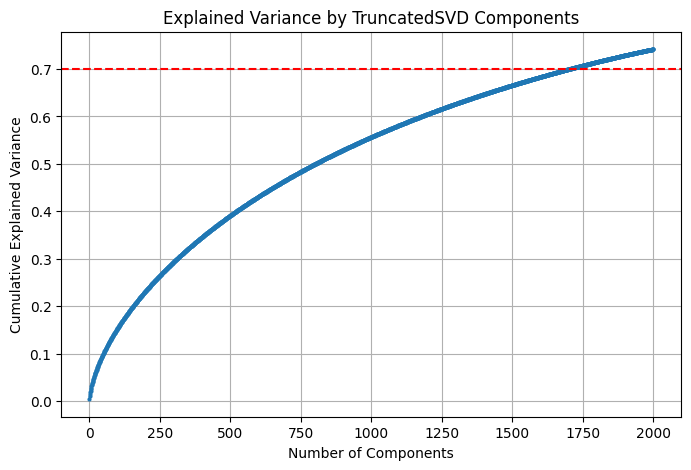

In [108]:
#reducing dimensions

import numpy as np

class ShiftTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Determine the shift value needed to make all values non-negative
        self.shift_ = -X.min() if X.min() < 0 else 0
        return self

    def transform(self, X, y=None):
        return X + self.shift_
    
# --- Optimal n_components Selection via Explained Variance Analysis ---
# Set a high number of components to analyze the explained variance
max_components = 2000
svd_full = TruncatedSVD(n_components=max_components, random_state=42)
svd_full.fit(X_train_tfidf)
cumulative_variance = np.cumsum(svd_full.explained_variance_ratio_)
# Set threshold for desired explained variance (e.g., 70%)
threshold = 0.70
optimal_n_components = np.argmax(cumulative_variance >= threshold) + 1  # +1 because index starts at 0

plt.close('all')
print(f"\nOptimal n_components based on {threshold*100:.0f}% explained variance: {optimal_n_components}")
# Optional: Plot the cumulative explained variance curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_components + 1), cumulative_variance, marker='o', markersize=2)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by TruncatedSVD Components')
plt.grid(True)
plt.show()

Now we will test the classifiers with that number of components.

In [ ]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

print(f"\n=== Running SVD with n_components={optimal_n_components} ===\n")

# Create SVD pipeline
svd_pipeline = make_pipeline(
    TruncatedSVD(n_components=optimal_n_components, random_state=42),
    ShiftTransformer(),          # Shift data to remove negatives
    Normalizer(copy=False)       # Normalizer is important for kNN and Naive Bayes
)

# Apply SVD transformation
X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
X_test_svd = svd_pipeline.transform(X_test_tfidf)


svd_results = evaluate_classifiers(
    classifiers, X_train_svd, X_test_svd, y_train, y_test, "SVD Reduced"
)
results_df_svd = pd.DataFrame(svd_results)
results_df_svd['Dimensions'] = "SVD Reduced"
styled_df_svd = (
    format_results_table(results_df_svd, groupby='n_components').style
    .set_caption("Results for SVD Reduced Data")
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })
)
display(styled_df_svd)


=== Running SVD with n_components=1704 ===


=== Running classifiers on SVD Reduced data (1704 features) ===

Completed: Logistic Regression on SVD Reduced data
Completed: Ridge Classifier on SVD Reduced data
Completed: Decision Tree on SVD Reduced data


Although we expected that reducing the dimensionality from 13,171 to 1,704 features might improve performance and lower training times, we found the opposite. First, many of the chosen classifiers (e.g., Complement Naive Bayes, and LinearSVC) handle high-dimensional, sparse data very effectively for text tasks. When we apply TruncatedSVD, we risk losing valuable discriminative information, causing a drop in accuracy.

Second, after SVD, the data becomes dense rather than sparse, which can actually slow down training for certain models, such as tree-based classifiers (Decision Tree, Random Forest) and KNN. This overhead can outweigh the benefit of having fewer dimensions. So while dimensionality reduction can be beneficial in some contexts, it can also degrade both speed and accuracy when working with text data and classifiers that naturally handle high-dimensional, sparse input.

## Feature Agglomeration
We want to check if reducing the feature space from 13171 to smaller space using feature agglomeration might help us preform better.
In order to do so we need to turn our sparse data to dense data and rerun our classifiers.

In [ ]:
# Reduce the number of features by clustering similar features together.
# Note: FeatureAgglomeration requires dense input, so we convert the TF-IDF matrices.
# Adjust n_clusters to suit your balance of dimensionality vs. information.
n_clusters = 1704
fa = FeatureAgglomeration(n_clusters=n_clusters)

# Convert sparse matrices to dense arrays before agglomeration.
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

X_train_reduced = fa.fit_transform(X_train_dense)
X_test_reduced = fa.transform(X_test_dense)

In [ ]:
# Evaluate classifiers on the reduced data
results_tfidf_reduced = evaluate_classifiers(classifiers, X_train_reduced, X_test_reduced, y_train, y_test, "Feature-Agglomeration")

# Convert the results list to DataFrames
results_df_tfidf_reduced = pd.DataFrame(results_tfidf_reduced)

# Format and display the TF-IDF results table
styled_df_tfidf_reduced = (
    format_results_table(results_df_tfidf_reduced, groupby='n_components').style \
    .set_caption("Results for Feature-Agglomeration Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    }))
display(styled_df_tfidf_reduced.hide())



## Hyperparameter Optimization Using GridSearchCV
The parameters we initially gave to the classifiers where generic and not optimized, so in this stage we will use GridSearchCV in order to find the optimal parameters for each classifier so we can get the best out of them and we will use them from now on.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define classifiers along with their parameter grids
classifiers_to_opt = [
    ('Logistic Regression', 
     LogisticRegression(random_state=42, max_iter=1000),
     {'C': [0.1, 1, 10, 100],
      'solver': ['lbfgs', 'liblinear']}),
    
    ('Decision Tree', 
     DecisionTreeClassifier(random_state=42),
     {'max_depth': [None, 5, 10, 20],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': [None, 'sqrt', 'log2']}),
    
    ('Random Forest', 
     RandomForestClassifier(random_state=42),
     {'n_estimators': [20, 50, 100],
      'max_features': ['sqrt', 'log2'],
      'max_depth': [None, 5, 10, 20]}),
    
    ('LinearSVC', 
     LinearSVC(random_state=42, dual=True, max_iter=10000),
     {'C': [0.01, 0.1, 1, 10, 100]}),
    
    ('KNN', 
     KNeighborsClassifier(),
     {'n_neighbors': [7, 9, 11, 13],
      'weights': ['uniform', 'distance'],
      'metric': ['euclidean', 'manhattan', 'cosine']}),
    
    ('Complement Naive Bayes', 
    #  MultinomialNB(),
     ComplementNB(),
    {'alpha': [0.1, 1, 10]}),

    ('Ridge Classifier',
     RidgeClassifier(random_state=42, tol=1e-2,solver="sparse_cg"),
     {'alpha': [0.1, 1, 10]})
]

# Dictionary to store the grid search results for each classifier
grid_search_results = {}

# Loop over classifiers and perform grid search
for name, clf, param_grid in classifiers_to_opt:
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_tfidf, y_train)
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation score for {name}: {grid_search.best_score_:.4f}\n")
    grid_search_results[name] = grid_search

In [ ]:
# Evaluate each optimized (best) classifier on the test set using your evaluation functions
optimized_results = []
optimized_confusion_figures = []
print("\n=== Evaluating Optimized Classifiers on TF-IDF Data ===\n")
for clf_name, grid in grid_search_results.items():
    best_model = grid.best_estimator_ # This model has the optimal parameters
    result = get_classifier_metrics(best_model, X_train_tfidf, X_test_tfidf, y_train, y_test, clf_name, to_fit=False)
    result['Best Parameters'] = grid.best_params_
    result['n_components'] = X_train_tfidf.shape[1]
    optimized_results.append(result)
    print(f"Completed: {clf_name} (Optimized)")


results_df_optimized = pd.DataFrame(optimized_results)
results_df_optimized.drop(columns=['Training Time (s)'], inplace=True)

styled_df_optimized = format_results_table(results_df_optimized, groupby='n_components').style \
    .set_caption("Results for Optimized TF-IDF Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

styled_df_optimized.hide()
display(styled_df_optimized.hide())

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def print_most_confused_pairs(y_true, results, target_names=None):
    
    # Get unique numeric labels from y_true (assumes labels are numeric)
    class_labels = np.unique(y_true)
    
    for res in results:
        clf_name = res['Classifier']
        y_pred = res['y_pred']
        # Compute the confusion matrix using the ordering of class_labels
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        # Make a copy and replace the diagonal with -1 to ignore correct predictions
        cm_no_diag = cm.copy()
        np.fill_diagonal(cm_no_diag, -1)
        
        # Find the indices (i, j) of the largest off-diagonal entry
        i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
        max_confusion = cm_no_diag[i, j]
        total_files = int(cm[i, :].sum() + cm[j, :].sum())
        
        # Map numeric labels to class names if target_names is provided
        if target_names is not None:
            actual_class = target_names[class_labels[i]]
            predicted_class = target_names[class_labels[j]]
        else:
            actual_class = class_labels[i]
            predicted_class = class_labels[j]
            
        if max_confusion <= 0:
            print(f"{clf_name}: No significant misclassification found.")
        else:
            print(f"=={clf_name}==: \nActual '{actual_class}' predicted '{predicted_class}' \nwith {max_confusion} misclassifications \nout of total {total_files} files.\n")



print_most_confused_pairs(y_test, optimized_results, target_names)


for name, _ in classifiers:
    fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure for better readability
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        classifiers_predictions[name],
        display_labels=target_names,  # Use your list of class names
        cmap='Blues',                 # Friendlier color map
        values_format='d',            # Show integer counts
        xticks_rotation='vertical',   # Rotate x-ticks if labels overlap
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"Confusion Matrix: {name} (TF-IDF)", fontsize=16)
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)
    plt.tight_layout()  # Ensures labels and titles fit nicely
    plt.show()